In [1]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
import shap
from collections import defaultdict
import re

In [2]:
cali_housing_path = '../data/California_Houses.csv'
RANDOM_SEED = 492
cali_df = pd.read_csv(cali_housing_path)
y_series = cali_df['Median_House_Value']
y = pd.DataFrame(y_series, columns=['Median_House_Value'])
features = [col for col in cali_df.columns if col != 'Median_House_Value']
X = cali_df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [80]:
class GradientBoostedTreesEnsembleRegressor(tf.keras.Model):
    def __init__(self, n_trees=100, max_depth=3, n_estimators=100, subportion = 0.8, sample_method = "RANDOM",verbose = 1): 
        super(GradientBoostedTreesEnsembleRegressor, self).__init__()
        self.n_trees = n_trees
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.subportion = subportion
        self.sample_method = sample_method
        self.verbose = verbose
        self.estimators = []
        self.lime_explainers = []
        self.shap_explainers = []

    def build_estimator(self):
        model = tfdf.keras.GradientBoostedTreesModel(
            task=tfdf.keras.Task.REGRESSION,
            num_trees=np.random.randint(self.n_trees//5, self.n_trees+1), # self.n_trees, #
            max_depth=self.max_depth, #np.random.randint(self.max_depth/2, self.max_depth+1), # self.max_depth, # 
            validation_ratio=0.1,
            subsample=self.subportion,
            sampling_method=self.sample_method,
            random_seed=self.seed, # try to set this first. Maybe this is enough
            verbose=1
        )
        return model
    
    # if not, the number of trees/depth different for each estimator

    def fit(self, X, y):
        
        X_tensor = tf.constant(X.values, dtype=tf.float32)
        y_tensor = tf.constant(y.values, dtype=tf.float32)
        tot_dataset_size = len(X)
        
        for seed in np.random.randint(0, 1000000, size=self.n_estimators):
            self.seed = int(seed)
            subset_size = int(self.subportion * tot_dataset_size)
            
            # Create a subset of the dataset using sampled indices
            subset_indices = np.random.choice(tot_dataset_size, size=subset_size, replace=False)
            X_subset = tf.gather(X_tensor, subset_indices)
            y_subset = tf.gather(y_tensor, subset_indices)
            
            # subset_dataset = (X_tensor, y_tensor)
            
            # building each estimator
            estimator = self.build_estimator()
            estimator.fit(X_subset,y_subset,verbose=0)
            self.estimators.append(estimator)
            
        # initiate explainers
        for model in self.estimators:
            lime_explainer = LimeTabularExplainer(X.values, feature_names=X.columns.tolist(), mode='regression')
            self.lime_explainers.append(lime_explainer)
            masker = shap.maskers.Independent(data = X_train.values)
            shap_explainer = shap.Explainer(model, masker=masker, feature_names=X.columns.tolist())
            self.shap_explainers.append(shap_explainer)
    
    #something's not right here
    def predict_mean(self, X):
        predictions = []
        
        for estimator in self.estimators:
            estimator_predictions = estimator.predict(X,verbose=0)  # Get predictions from the current estimator
            predictions.append(estimator_predictions)
        
        # Stack all predictions along the last axis (-1)
        predictions_stacked = tf.stack(predictions, axis=-1)
        
        # Compute mean and variance across the stacked predictions
        mean_prediction = tf.reduce_mean(predictions_stacked, axis=-1)
        sd_prediction = tf.math.reduce_std(predictions_stacked, axis=-1)
        
        return mean_prediction, sd_prediction
    
    def explain_lime(self, X):
        lime_explanations = []
        
        for estimator, explainer in zip(self.estimators, self.lime_explainers):
            for i in range(len(X)): 
                instance_explanation = explainer.explain_instance(X.iloc[i], estimator.predict, num_features=X.shape[1])
                lime_explanations.append(instance_explanation)
        return lime_explanations
    
    def explain_shap(self, X):
        shap_values = []
        
        for estimator, explainer in zip(self.estimators, self.shap_explainers):
            shap_value = explainer(X)
            shap_values.append(shap_value)
        
        return shap_values
    

In [81]:
gbt_model = GradientBoostedTreesEnsembleRegressor(
    n_trees=50, 
    max_depth=5, 
    n_estimators=80, 
    subportion=0.8, 
    sample_method='RANDOM',
    verbose=1
)

In [82]:
gbt_model.compile(metrics=["mse"])

In [83]:
gbt_model.fit(X_train_scaled, y_train)

Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpp0y47b2q as temporary training directory


[WARNING 24-07-02 16:40:16.9685 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:40:16.9685 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:40:16.9685 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmp06e_dnox as temporary training directory


[INFO 24-07-02 16:40:18.1903 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpp0y47b2q/model/ with prefix 1d4ceda986174a57
[INFO 24-07-02 16:40:18.1931 CEST abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 24-07-02 16:40:18.1932 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-02 16:40:18.2997 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:40:18.2998 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:40:18.2998 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpb7z2vb6j as temporary training directory


...

[INFO 24-07-02 16:41:30.4685 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpktnkh4v_/model/ with prefix eac22a3463b449d3
[INFO 24-07-02 16:41:30.4695 CEST abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 24-07-02 16:41:30.4695 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-02 16:41:30.5696 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:41:30.5698 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:41:30.5699 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpr7i9v9rv as temporary training directory


[INFO 24-07-02 16:41:31.7540 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpmtvwqrtq/model/ with prefix e4f65107b6f34797
[INFO 24-07-02 16:41:31.7576 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-02 16:41:31.8503 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:41:31.8503 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:41:31.8504 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpjv0rg14h as temporary training directory


[INFO 24-07-02 16:41:32.3536 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpr7i9v9rv/model/ with prefix 66c15a098b654bec
[INFO 24-07-02 16:41:32.3554 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-02 16:41:32.4642 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:41:32.4643 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-02 16:41:32.4644 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
[INFO 24-07-02 16:41:32.8916 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpjv0rg14h/model/ with prefix 27ed1003fc864951
[INFO 24-07-02 16:41:32.8922 CEST kernel.cc:1061] Use fast generic engine


In [84]:
mean_predict, variance_predict = gbt_model.predict_mean(X_test_scaled)

In [85]:
# evaluation with mse
y_test_eval = np.array(y_test).flatten()
y_pred_eval = mean_predict.numpy().flatten()
root_mse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
print(root_mse)

60479.06839434712


In [86]:
# make a dataframe to save somethings
# y-test
gbt_cali_data = pd.DataFrame({'y_test':y_test_eval})
# predicted mean
gbt_cali_data['mean_predict'] = mean_predict
# predicted std
gbt_cali_data['predicted_uncertainty'] = variance_predict

In [99]:
print(gbt_cali_data.head())

     y_test   mean_predict  predicted_uncertainty
0  273700.0  312351.562500           13838.806641
1   66900.0   78135.671875           15792.422852
2  258700.0  192267.250000            5868.218750
3  183400.0  194073.671875            4412.804199
4  265600.0  257612.953125           10016.541016


In [88]:
gbt_cali_data.to_csv('../results/gbt_cali_data.csv')

In [89]:
sorted_gbt_cali_data = gbt_cali_data.sort_values(by='predicted_uncertainty')

In [90]:
print(sorted_gbt_cali_data)

        y_test   mean_predict  predicted_uncertainty
1112  204600.0  207582.703125            3081.685791
2904  201600.0  207054.828125            3192.156738
4006  206100.0  206854.343750            3194.381348
664   203500.0  208812.781250            3211.910645
2886  207200.0  209905.796875            3221.571289
...        ...            ...                    ...
3491  500001.0  330611.906250           43693.441406
2639  500001.0  390385.156250           45789.812500
2905  500001.0  400222.656250           48269.105469
1326  466700.0  397523.343750           49475.628906
128   500001.0  401991.656250           49678.765625

[4128 rows x 3 columns]


In [93]:
sorted_gbt_cali_data.to_csv('../results/sorted_gbt_cali_data.csv')

In [94]:
# get the indices of the first three rows
first_three_indices = sorted_gbt_cali_data.index[:3]
# get the indices of the last three rows
last_three_indices = sorted_gbt_cali_data.index[-3:]
# combine the instances to be explained
combined_indices = first_three_indices.append(last_three_indices)
# select rows from X_test_scaled using these indices
X_test_scaled_selected = X_test_scaled.loc[combined_indices]

In [95]:
print(combined_indices)

Index([1112, 2904, 4006, 2905, 1326, 128], dtype='int64')


In [96]:
print(X_test_scaled_selected)

      Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  Population  \
1112       0.204393   -0.294257   1.532613      1.470086    2.737771   
2904       0.232674    0.342124   0.716236      0.634943    0.550695   
4006       0.204498   -1.010185   1.534459      1.769881    1.484106   
2905       0.299413    1.853528   0.466570      0.720599    0.088400   
1326       0.124799    1.853528   0.250592      0.739633   -0.146276   
128        0.177005    1.853528   0.272282      1.027531   -0.240676   

      Households  Latitude  Longitude  Distance_to_coast  Distance_to_LA  \
1112    1.485636 -0.863799   0.881501          -0.353718       -0.887962   
2904    0.880902 -0.807662   0.836567          -0.278714       -0.944784   
4006    1.866882 -0.826375   0.886493          -0.197624       -0.903486   
2905    0.780990  1.007441  -1.430094          -0.804284        1.176213   
1326    0.807282  1.012119  -1.425102          -0.796663        1.177031   
128     0.870385  1.007441  -1.425102  

In [30]:
gbt_cali_selected_explain_lime = []
for i in range(len(X_test_scaled_selected)): 
    gbt_cali_explain_lime_instance = gbt_model.explain_lime(X_test_scaled.loc[[i]])
    gbt_cali_selected_explain_lime.append(gbt_cali_explain_lime_instance)

  1/157 [..............................] - ETA: 16s

/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ trea

157/157 [==============================] - 0s 1ms/step


/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

 29/157 [====>.........................] - ETA: 0s

...

/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

  9/157 [>.............................] - ETA: 1s

/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

157/157 [==============================] - 0s 2ms/step


/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

In [31]:
for i in range(len(X_test_scaled_selected)):
    def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
    def sort_features_by_name(explanation):
        # Extract the features and their weights
        features_weights = explanation.as_list()
        # Sort the features based on their names
        sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
        return sorted_features_weights
    feature_weights = defaultdict(list)
    for explanation in gbt_cali_selected_explain_lime[i]:
        sorted_features = sort_features_by_name(explanation)
        for feature, weight in sorted_features:
            feature_weights[feature].append(weight)
            
    print(feature_weights)

defaultdict(<class 'list'>, {'Median_Income > 0.46': [152767.26753107688, 142640.42418475111, 147146.7031758068, 134910.14427331052, 152625.84849797536, 144747.11526445768, 127549.4731811039, 134674.65387467612, 145865.1896424964, 146014.05368226237, 117312.90958862824, 147012.22442533946, 151967.02110367286, 149012.31942802982, 147191.4099384332, 132708.8193793884, 147011.1415332525, 137325.14350517353, 152091.36543571053, 139087.81246294448, 142005.13324617606, 145127.16918401298, 145432.52218484136, 149212.09968050133, 144395.34447299197, 129113.9141285074, 147951.71417203534, 115159.3478016238, 113740.02145045795, 153841.47180135082, 149104.84851721267, 140863.34241450267, 149988.11687810274, 147704.92365014524, 132443.97677162403, 150694.96261582078, 150904.19300868563, 150398.34727821097, 150696.01887105417, 153825.71784178697, 150717.57527547824, 155500.5425014856, 138041.4844758983, 148851.59998304502, 146022.17156555215, 146143.94281378246, 149803.85279073854, 154305.780771569

In [36]:
gbt_cali_selected_lime_feature_stats=[]

for i in range(len(X_test_scaled_selected)):
    
    def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
    def sort_features_by_name(explanation):
        # Extract the features and their weights
        features_weights = explanation.as_list()
        # Sort the features based on their names
        sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
        return sorted_features_weights
    
    
    feature_w = defaultdict(list)
    
    for explanation in gbt_cali_selected_explain_lime[i]:
        sorted_features = sort_features_by_name(explanation)
        for feature, weight in sorted_features:
            feature_w[feature].append(weight)
    
    feature_stats = {}
    for feature, weights in feature_w.items():
        mean_weight = np.mean(weights)
        std_weight = np.std(weights)
        feature_stats[feature] = {'mean': mean_weight, 'std': std_weight}
    print(feature_stats)
    gbt_cali_selected_lime_feature_stats.append(feature_stats)

{'Median_Income > 0.46': {'mean': 144533.51903699705, 'std': 10152.965337406464}, '-0.39 < Distance_to_LA <= 1.04': {'mean': -11656.71869215272, 'std': 4596.75730310587}, 'Distance_to_SanFrancisco <= -1.08': {'mean': 4832.549001916398, 'std': 3312.6416821190955}, 'Population > 0.27': {'mean': -5655.4401533407345, 'std': 5431.55739200097}, 'Distance_to_SanJose <= -1.09': {'mean': 8638.722945144842, 'std': 3727.0368426106943}, '-0.64 < Latitude <= 0.97': {'mean': 3480.309750752908, 'std': 2394.0513079654306}, '-0.64 < Distance_to_coast <= -0.41': {'mean': 14158.512960818112, 'std': 2471.1433634936457}, 'Longitude <= -1.11': {'mean': 4941.716361865343, 'std': 3719.639531219122}, 'Median_Age <= -0.85': {'mean': -7181.903827520228, 'std': 1973.7297242013215}, 'Tot_Rooms > 0.24': {'mean': 3844.281710424526, 'std': 4573.205618777031}, '-0.23 < Households <= 0.28': {'mean': 192.78102539549405, 'std': 1865.1338953587094}, '-0.24 < Tot_Bedrooms <= 0.26': {'mean': 186.90959168535858, 'std': 2228.

In [29]:
    feature_to_column = {f'feature_{i}': col for i, col in enumerate(X_test_scaled.columns)}
    # Substitute feature_i with actual column names in feature_stats
    def replace_features(text, feature_to_column):
        pattern = re.compile(r'feature_\d+')
        matches = pattern.findall(text)
        for match in matches:
            text = text.replace(match, feature_to_column.get(match, match))
        return text
    
    # Substitute feature_i with actual column names in feature_stats
    updated_feature_stats = {}
    for feature, stats in feature_stats.items():
        new_feature = replace_features(feature, feature_to_column)
        updated_feature_stats[new_feature] = stats
    
    # Print the updated feature_stats
    print(updated_feature_stats)
    gbt_cali_selected_lime_feature_stats.append(updated_feature_stats)

{'Distance_to_coast <= -0.64': {'mean': 47042.641894437664, 'std': 7817.090340317845}, 'Distance_to_LA <= -0.96': {'mean': 25634.025670644925, 'std': 9974.028276311052}, '-0.18 < Median_Income <= 0.46': {'mean': -9069.691690250143, 'std': 2344.582185208022}, 'Latitude <= -0.80': {'mean': 10968.128846520693, 'std': 5262.674719665103}, '-0.85 < Median_Age <= 0.02': {'mean': -4007.2839838583777, 'std': 2406.1287936557856}, 'Distance_to_SanJose > 0.77': {'mean': -7140.808161864634, 'std': 3672.8545341664585}, '-0.24 < Tot_Bedrooms <= 0.26': {'mean': 800.1994489296765, 'std': 3112.9849617392474}, 'Distance_to_SanDiego <= -0.83': {'mean': -3810.7914569613176, 'std': 3064.7702097314186}, '-0.56 < Population <= -0.22': {'mean': 2806.519156172828, 'std': 3725.14226969759}, '0.54 < Longitude <= 0.78': {'mean': -1389.4756902181155, 'std': 3359.132147813081}, 'Distance_to_SanFrancisco > 0.79': {'mean': -4124.955949127281, 'std': 3474.829892673479}, '-0.23 < Households <= 0.28': {'mean': 203.283684

In [37]:
print(gbt_cali_selected_lime_feature_stats)

[{'Median_Income > 0.46': {'mean': 144533.51903699705, 'std': 10152.965337406464}, '-0.39 < Distance_to_LA <= 1.04': {'mean': -11656.71869215272, 'std': 4596.75730310587}, 'Distance_to_SanFrancisco <= -1.08': {'mean': 4832.549001916398, 'std': 3312.6416821190955}, 'Population > 0.27': {'mean': -5655.4401533407345, 'std': 5431.55739200097}, 'Distance_to_SanJose <= -1.09': {'mean': 8638.722945144842, 'std': 3727.0368426106943}, '-0.64 < Latitude <= 0.97': {'mean': 3480.309750752908, 'std': 2394.0513079654306}, '-0.64 < Distance_to_coast <= -0.41': {'mean': 14158.512960818112, 'std': 2471.1433634936457}, 'Longitude <= -1.11': {'mean': 4941.716361865343, 'std': 3719.639531219122}, 'Median_Age <= -0.85': {'mean': -7181.903827520228, 'std': 1973.7297242013215}, 'Tot_Rooms > 0.24': {'mean': 3844.281710424526, 'std': 4573.205618777031}, '-0.23 < Households <= 0.28': {'mean': 192.78102539549405, 'std': 1865.1338953587094}, '-0.24 < Tot_Bedrooms <= 0.26': {'mean': 186.90959168535858, 'std': 2228

In [38]:
# Flatten the dictionaries to create a list of dictionaries with mean and std as separate keys
flattened_data = []
for entry in gbt_cali_selected_lime_feature_stats:
    for feature, stats in entry.items():
        mean_value = stats['mean']
        std_value = stats['std']
        flattened_data.append((feature, mean_value, std_value))
    
# Create a DataFrame
gbt_cali_selected_lime_df = pd.DataFrame(flattened_data, columns=['Key', 'Mean', 'Std'])
print(gbt_cali_selected_lime_df)

                                        Key           Mean           Std
0                      Median_Income > 0.46  144533.519037  10152.965337
1            -0.39 < Distance_to_LA <= 1.04  -11656.718692   4596.757303
2         Distance_to_SanFrancisco <= -1.08    4832.549002   3312.641682
3                         Population > 0.27   -5655.440153   5431.557392
4              Distance_to_SanJose <= -1.09    8638.722945   3727.036843
..                                      ...            ...           ...
73    -0.83 < Distance_to_SanDiego <= -0.63    -108.726829   2401.494350
74  0.56 < Distance_to_SanFrancisco <= 0.79   -1654.590169   2820.878956
75                0.02 < Median_Age <= 0.66    3212.658109   2692.738481
76              -0.57 < Households <= -0.23    -994.291473   2392.485884
77       0.51 < Distance_to_SanJose <= 0.77   -3045.199723   2922.093826

[78 rows x 3 columns]


In [39]:
gbt_cali_selected_lime_df.to_csv('../results/gbt_selected_cali_lime.csv')

In [40]:
gbt_cali_selected_explain_shap = []
for i in range(len(X_test_scaled_selected)): 
    gbt_cali_explain_shap_instance = gbt_model.explain_shap(X_test_scaled.loc[[i]])
    gbt_cali_selected_explain_shap.append(gbt_cali_explain_shap_instance)

In [42]:
print(len(gbt_cali_selected_explain_shap[0]))

80


In [44]:
gbt_cali_selected_shap_stats=[]
for i in range(len(X_test_scaled_selected)):
    stacked_shap_values = np.vstack([gbt_cali_selected_explain_shap[i][j].values for j in range(len(gbt_cali_selected_explain_shap[i]))])
    mean_shap_values = np.mean(stacked_shap_values, axis=0)
    sd_shap_values = np.std(stacked_shap_values, axis=0)
    shap_features = X_test_scaled_selected.columns.tolist()
    gbt_cali_selected_shap_stats.append((shap_features, mean_shap_values, sd_shap_values))
print(gbt_cali_selected_shap_stats[0])

(['Median_Income', 'Median_Age', 'Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude', 'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego', 'Distance_to_SanJose', 'Distance_to_SanFrancisco'], array([-61975.03072548, -37532.72131584,   -558.15089003,  -1195.50243343,
          667.85592209,   -623.92022439,   7866.28877479,  -3431.39386428,
        85780.79659193,   1673.83928488,    604.96196039,  10157.71005672,
         6462.18573958]), array([11014.30958733,  7094.71403622,  1865.38641247,  2272.99544218,
        1327.70857311,  1808.05945304,  5254.75711617,  4645.36770958,
       19735.00532441,  4518.46462786,  2362.13170672,  9592.72582286,
        9729.29177936]))


In [46]:
# Initialize an empty list to collect the flattened data
flattened_shap_stats = []

for i in range(len(gbt_cali_selected_shap_stats)):
    shap_features, mean_shap_values, sd_shap_values = gbt_cali_selected_shap_stats[i]
    for feature, mean, std in zip(shap_features, mean_shap_values, sd_shap_values):
        flattened_shap_stats.append((feature, mean, std))

# Create the DataFrame
gbt_cali_selected_shap_df = pd.DataFrame(flattened_shap_stats, columns=['Feature', 'Mean', 'Std'])

# Display the DataFrame
print(gbt_cali_selected_shap_df)

                     Feature          Mean           Std
0              Median_Income -61975.030725  11014.309587
1                 Median_Age -37532.721316   7094.714036
2                  Tot_Rooms   -558.150890   1865.386412
3               Tot_Bedrooms  -1195.502433   2272.995442
4                 Population    667.855922   1327.708573
..                       ...           ...           ...
73         Distance_to_coast  75667.478996  13092.399230
74            Distance_to_LA  22385.023306  10265.386661
75      Distance_to_SanDiego  -4628.785757   3550.606111
76       Distance_to_SanJose   2359.199969   3877.107397
77  Distance_to_SanFrancisco   3633.000173   5940.838293

[78 rows x 3 columns]


In [47]:
gbt_cali_selected_shap_df.to_csv('../results/gbt_selected_cali_shap.csv')

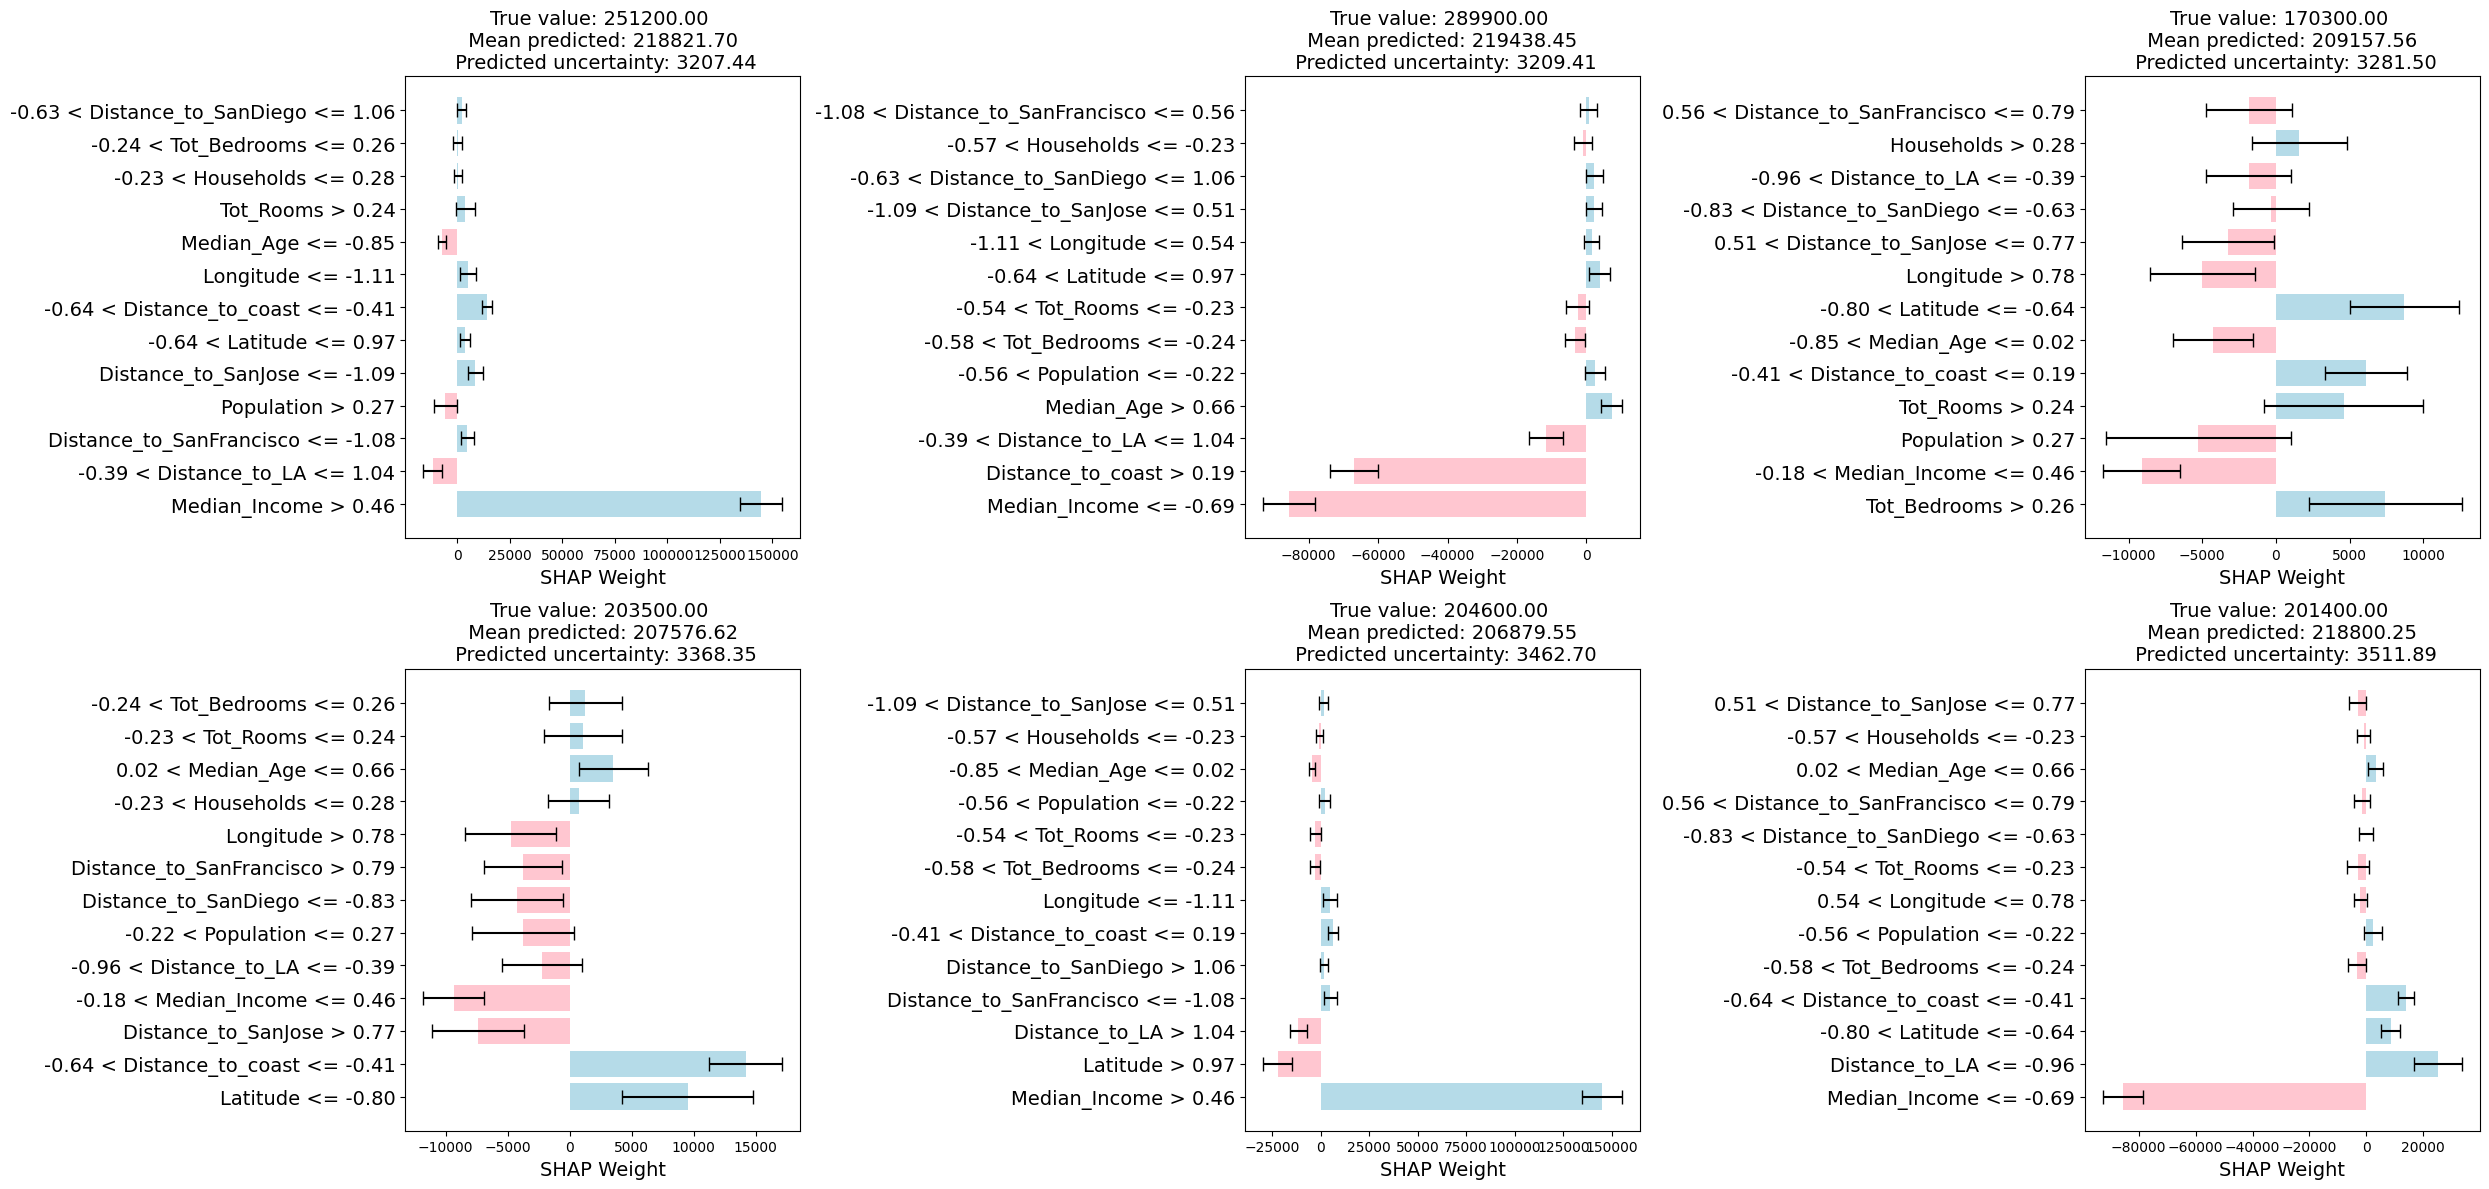

In [75]:
#original lime
# Extract data from the DataFrame
features_lime = gbt_cali_selected_lime_df['Key'].tolist()
mean_weights_lime = gbt_cali_selected_lime_df['Mean'].tolist()
std_weights_lime = gbt_cali_selected_lime_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_lime]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = int(np.ceil(len(features_lime) / features_per_plot))

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(25, 12))
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots
for i in range(num_plots):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_lime))
    
    # Get the data for this range
    chunk_features = features_lime[start_idx:end_idx]
    chunk_mean_weights = mean_weights_lime[start_idx:end_idx]
    chunk_std_weights = std_weights_lime[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14)
    axes[i].set_xlabel("SHAP Weight", fontsize=14)
    title_true = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('y_test')]
    title_mean = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('mean_predict')]
    title_uncertainty = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('predicted_uncertainty')]
    axes[i].set_title(f"True value: {title_true:.2f} \n Mean predicted: {title_mean:.2f} \n Predicted uncertainty: {title_uncertainty:.2f}", fontsize=14)
    
# Adjust layout
plt.tight_layout()
plt.show()

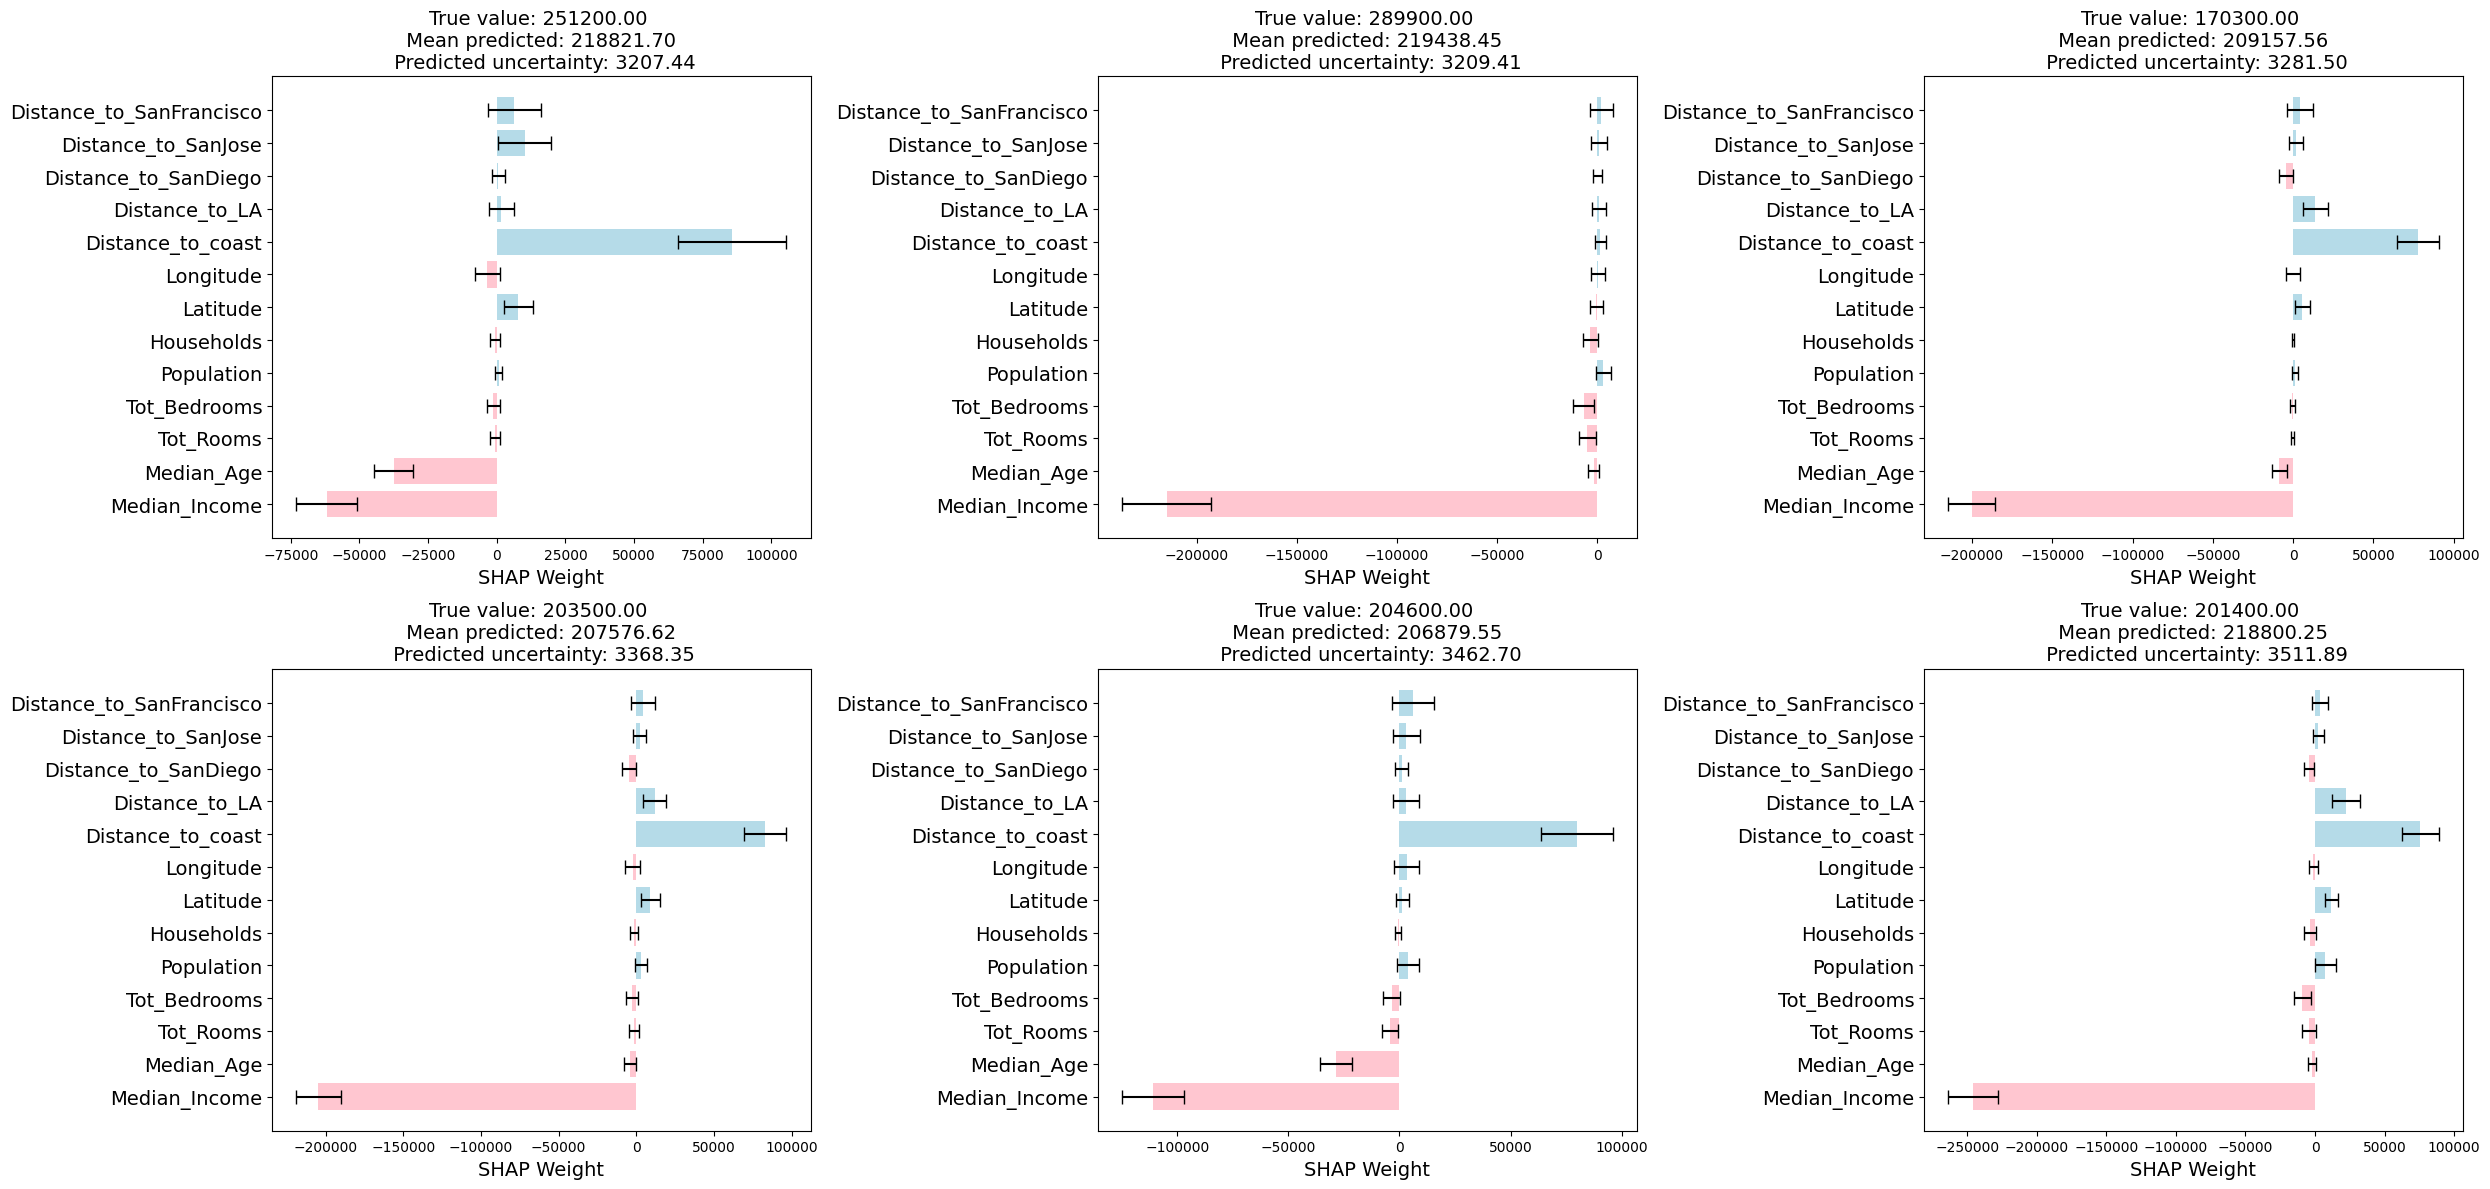

In [74]:
# original shap
# Extract data from the DataFrame
features_shap = gbt_cali_selected_shap_df['Feature'].tolist()
mean_weights_shap = gbt_cali_selected_shap_df['Mean'].tolist()
std_weights_shap = gbt_cali_selected_shap_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_shap]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = int(np.ceil(len(features_shap) / features_per_plot))

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(25, 12))
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots
for i in range(num_plots):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_shap))
    
    # Get the data for this range
    chunk_features = features_shap[start_idx:end_idx]
    chunk_mean_weights = mean_weights_shap[start_idx:end_idx]
    chunk_std_weights = std_weights_shap[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14)
    axes[i].set_xlabel("SHAP Weight", fontsize=14)
    title_true = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('y_test')]
    title_mean = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('mean_predict')]
    title_uncertainty = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('predicted_uncertainty')]
    axes[i].set_title(f"True value: {title_true:.2f} \n Mean predicted: {title_mean:.2f} \n Predicted uncertainty: {title_uncertainty:.2f}", fontsize=14)
    
# Adjust layout
plt.tight_layout()
plt.show()

In [100]:
# Get model weights
weights = gbt_model.get_weights()

In [98]:
print(weights)

[]
